# PCA and eigenfaces

We work with a face image library stored in `allFaces.mat`. Each grayscale face image is reshaped into a column vector, and we use **principal component analysis (PCA)** through the **singular value decomposition (SVD)** to build a low-dimensional coordinate system of **eigenfaces**.

The main goals are:

1. build the mean face and the mean-subtracted data matrix,
2. compute the eigenfaces from the SVD,
3. inspect the singular values and cumulative explained variance,
4. reconstruct a test face using different numbers of principal components,
5. visualize how images of different people separate in PCA coordinates,
6. perform a very simple recognition experiment in eigenface space.


## Learning goals

By the end of this notebook, you should be able to:

- load and organize a face image dataset for PCA,
- compute the mean face and mean-subtracted training matrix,
- compute eigenfaces from the economy SVD,
- interpret singular values in terms of variance and dimensionality reduction,
- reconstruct a face using a truncated PCA basis,
- project face images into a low-dimensional PCA space,
- understand why PCA can help with simple face recognition.


## 1. Load the face dataset and visualize a few images

We use the file `allFaces.mat`, which is placed in the local `data/` folder.

The dataset contains:

- `faces`: a matrix whose columns are vectorized face images,
- `n` and `m`: the image height and width,
- `nfaces`: the number of images available for each person.

Each column of `faces` is one aligned grayscale image.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

def load_face_data():
    mat = loadmat("data/allFaces.mat")
    faces = np.asarray(mat["faces"], dtype=np.float32)
    n = int(np.array(mat["n"]).squeeze())
    m = int(np.array(mat["m"]).squeeze())
    nfaces = np.asarray(mat["nfaces"]).flatten().astype(int)

    return faces, n, m, nfaces

def face_image(vec, n, m):
    return vec.reshape((m, n)).T

def show_face(vec, n, m, ax=None, title=None, cmap="gray"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(face_image(vec, n, m), cmap=cmap)
    ax.axis("off")
    if title is not None:
        ax.set_title(title)

def person_ranges(nfaces):
    starts = np.cumsum(np.concatenate(([0], nfaces[:-1])))
    stops = np.cumsum(nfaces)
    return list(zip(starts, stops))


In [3]:
faces, n, m, nfaces = load_face_data()

print("faces shape:", faces.shape)
print("image size:", n, "x", m)
print("number of people:", len(nfaces))
print("first 10 values of nfaces:", nfaces[:10])


faces shape: (32256, 2410)
image size: 192 x 168
number of people: 38
first 10 values of nfaces: [64 62 64 64 62 64 64 64 64 64]


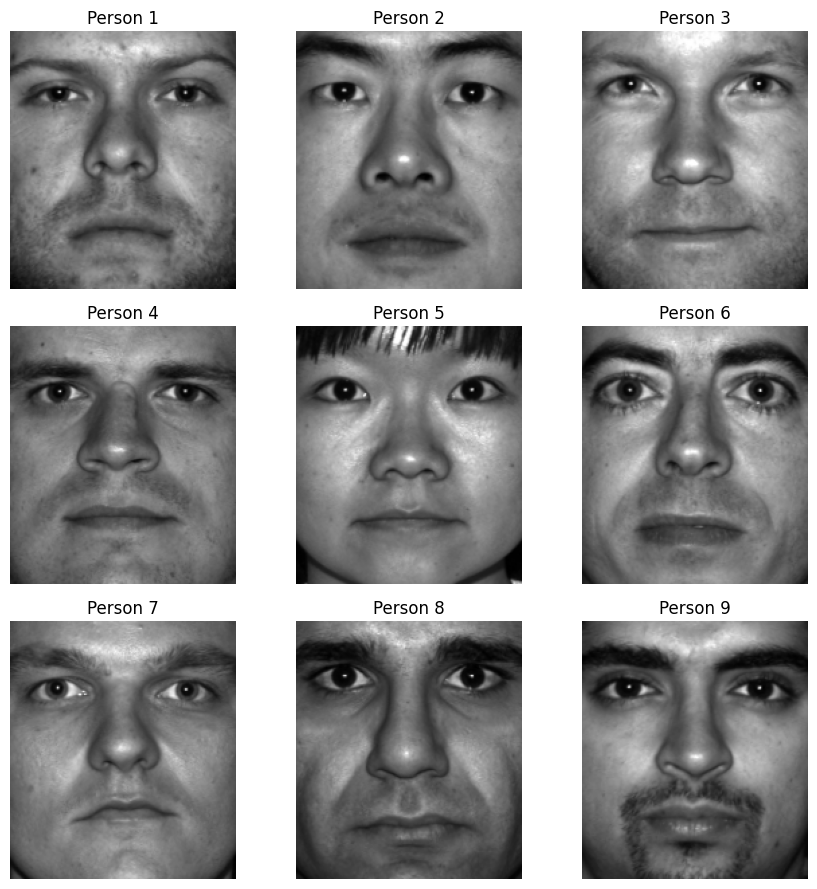

In [7]:
ranges = person_ranges(nfaces)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for j, ax in enumerate(axes.flat):
    start, stop = ranges[j]
    show_face(faces[:, start], n, m, ax=ax, title=f"Person {j+1}")

plt.tight_layout()
plt.show()


## 2. Build the training set and compute the mean face

We use the **first 36 people** as training data and keep the remaining two people as a small test set.

We then compute the average face of the training set and subtract it from every training image.


In [13]:
n_train_people = 36
n_train = int(np.sum(nfaces[:n_train_people]))

training_faces = faces[:, :n_train]
avg_face = np.mean(training_faces, axis=1)
X = training_faces - avg_face[:, None]

print("training_faces shape:", training_faces.shape)
print("mean-subtracted matrix shape:", X.shape)


training_faces shape: (32256, 2282)
mean-subtracted matrix shape: (32256, 2282)


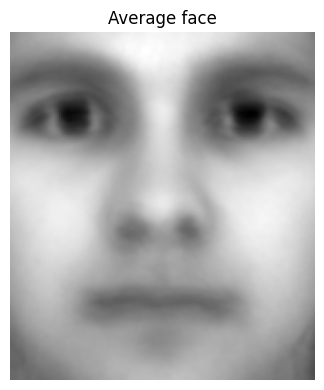

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
show_face(avg_face, n, m, ax=ax, title="Average face")
plt.tight_layout()
plt.show()


## 3. Compute PCA from the SVD

We compute the economy SVD of the mean-subtracted training matrix:
$$
X = U\Sigma V^T.
$$

In this setting:

- the columns of $U$ are the **eigenfaces**,
- the singular values indicate the importance of each component,
- the columns of $V$ contain the PCA coordinates of the training images, up to scaling by $\Sigma$.


In [15]:
U, s, VT = np.linalg.svd(X, full_matrices=False)

#To save memory 
del X, VT
import gc
gc.collect()

3963

## 4. Visualize the first eigenfaces

The first few eigenfaces describe dominant patterns of variation in the training images.

They are not actual faces, but basis images that span the dominant directions of variation in the dataset.


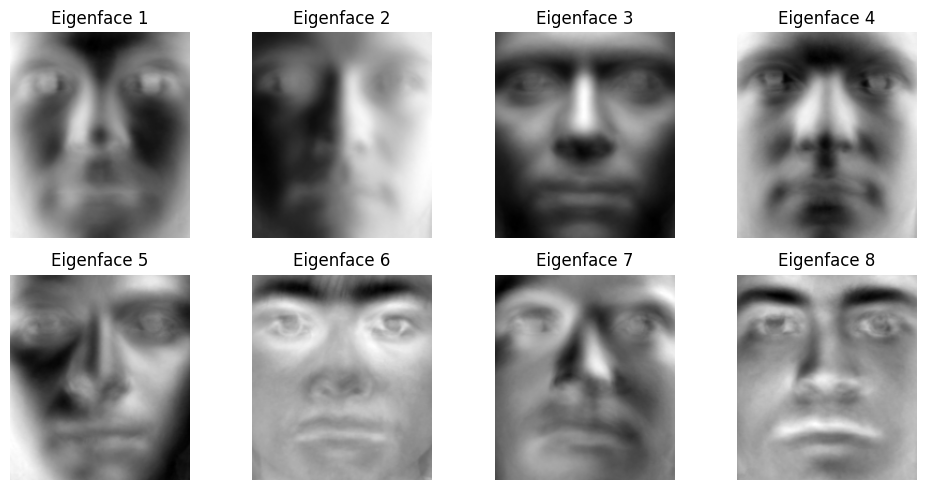

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for j, ax in enumerate(axes.flat):
    show_face(U[:, j], n, m, ax=ax, title=f"Eigenface {j+1}")
plt.tight_layout()
plt.show()


## 5. Singular values and cumulative explained variance

We now inspect how quickly the singular values decay and how much variance is captured by the first principal components.

This helps us understand why a relatively small number of components can already provide a useful approximation of a face.


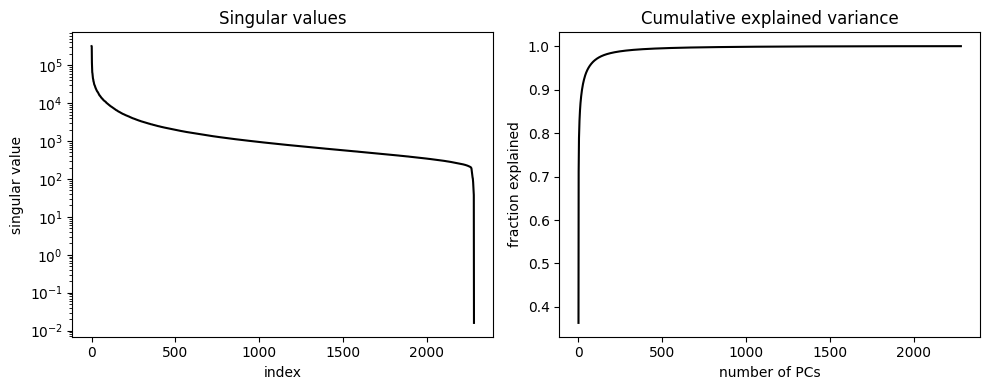

In [17]:
explained_variance = s**2 / np.sum(s**2)
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].semilogy(s, "k")
axes[0].set_title("Singular values")
axes[0].set_xlabel("index")
axes[0].set_ylabel("singular value")

axes[1].plot(cumulative_variance, "k")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("number of PCs")
axes[1].set_ylabel("fraction explained")

plt.tight_layout()
plt.show()


## 6. Reconstruct a test face with different numbers of components

We now choose a test image from a person **outside the training set** and reconstruct it using truncated PCA bases of different sizes.

If $U_r$ contains the first $r$ eigenfaces, then the rank-$r$ reconstruction is
$$
x_{\mathrm{recon}} = \bar{x} + U_r U_r^T (x_{\mathrm{test}} - \bar{x}).
$$


In [18]:
test_idx = int(np.sum(nfaces[:36])) # first image of person 37
test_face = faces[:, test_idx]
test_face_ms = test_face - avg_face

r_values = [25, 100, 200, 400, 800]


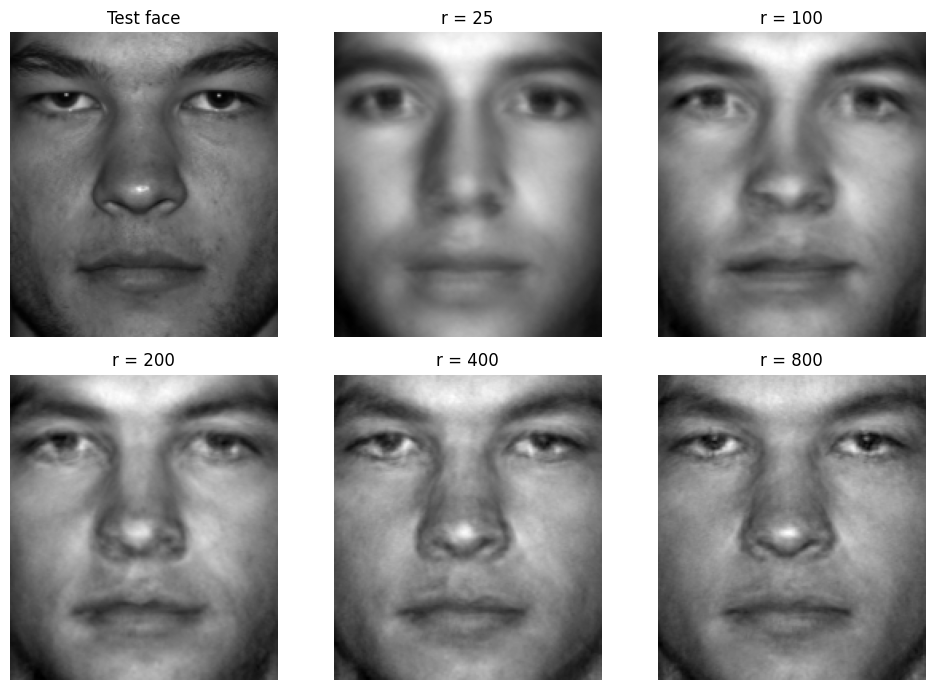

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

show_face(test_face, n, m, ax=axes[0, 0], title="Test face")

for ax, r in zip(axes.flat[1:], r_values):
    recon = avg_face + U[:, :r] @ (U[:, :r].T @ test_face_ms)
    show_face(recon, n, m, ax=ax, title=f"r = {r}")

plt.tight_layout()
plt.show()


## 7. Project two people onto a two-dimensional PCA space

Images of different people may separate in a low-dimensional PCA projection.

We reproduce this idea by taking two specific people and projecting all of their images onto the **5th and 6th principal components**.


In [27]:
P1num = 2
P2num = 7

ranges = person_ranges(nfaces)
P1_start, P1_stop = ranges[P1num - 1]
P2_start, P2_stop = ranges[P2num - 1]

P1 = faces[:, P1_start:P1_stop] - avg_face[:, None]
P2 = faces[:, P2_start:P2_stop] - avg_face[:, None]

pc_modes = [4, 5]   # Python indexing for PCs 5 and 6

coords_P1 = U[:, pc_modes].T @ P1
coords_P2 = U[:, pc_modes].T @ P2


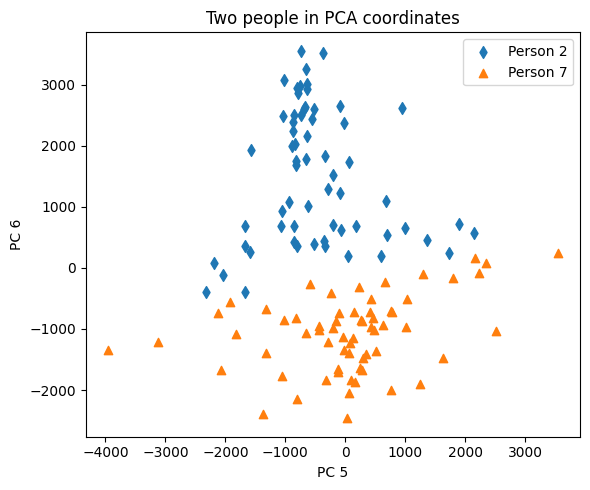

In [28]:
plt.figure(figsize=(6, 5))
plt.scatter(coords_P1[0, :], coords_P1[1, :], label=f"Person {P1num}", marker="d")
plt.scatter(coords_P2[0, :], coords_P2[1, :], label=f"Person {P2num}", marker="^")

plt.xlabel("PC 5")
plt.ylabel("PC 6")
plt.title("Two people in PCA coordinates")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Approximate a dog image using the eigenface basis

An eigenface basis, although trained on faces, can also be used to approximate a non-face image.

We reproduce that idea here using the dog image `dog.jpg`, stored in the `data/` folder.

The image is **not** part of the face training set. We convert it to grayscale, resize it to the same dimensions as the face images, subtract the average face, and then project it onto the eigenface basis.


In [29]:
from PIL import Image
# Load the dog image, convert it to grayscale, and resize it
img = Image.open("data/dog.jpg").convert("L")
img = img.resize((m, n))

# Turn the image into a vector with the same format as the face data
dog = np.asarray(img, dtype=float).T.reshape(-1)
dog_ms = dog - avg_face

r_values_dog = [25, 100, 400, 800, 1600]


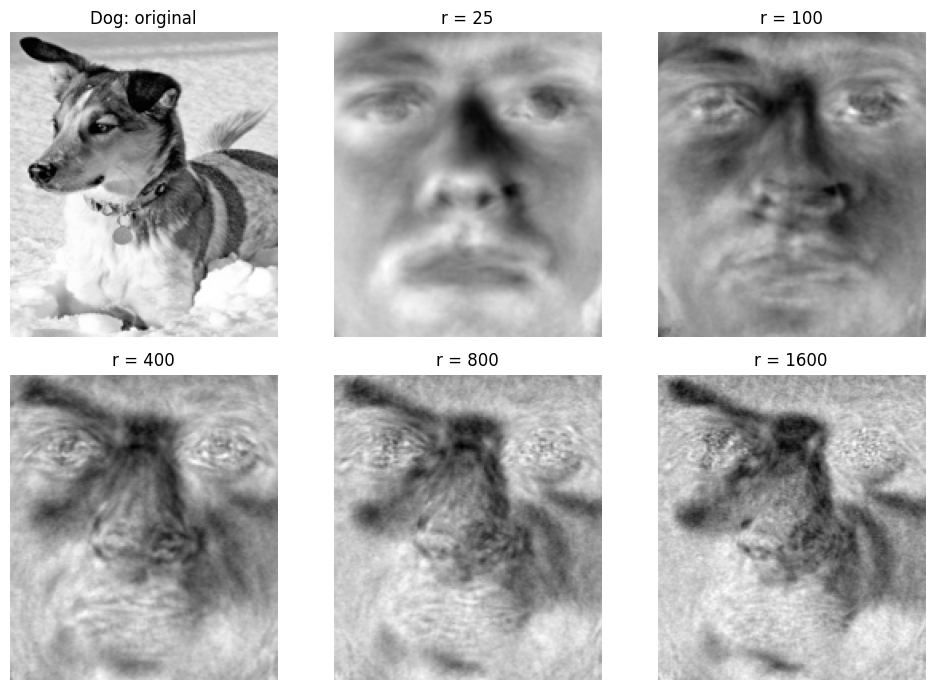

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

show_face(dog, n, m, ax=axes[0, 0], title="Dog: original")

for ax, r in zip(axes.flat[1:], r_values_dog):
    recon = avg_face + U[:, :r] @ (U[:, :r].T @ dog_ms)
    show_face(recon, n, m, ax=ax, title=f"r = {r}")

plt.tight_layout()
plt.show()


At low rank, the reconstruction looks face-like and distorted. As the number of retained eigenfaces increases, the dog becomes more recognizable. This happens because the eigenface basis spans a broad low-dimensional subspace of smooth image features, even though it is still better adapted to faces than to dogs.


## Final discussion

1. **Why do we subtract the mean face before applying PCA?**  
   Because PCA is designed to capture directions of variation around the average. Without mean subtraction, the first component would be dominated by the overall average brightness pattern.

2. **What do the first eigenfaces represent?**  
   They represent dominant patterns of variation shared across the training images, such as global lighting changes, facial proportions, and large-scale contrasts.

3. **Why can a face often be approximated well with far fewer components than the number of pixels?**  
   Because face images are highly correlated: many pixels vary together in structured ways, so the effective dimensionality is much smaller than the raw pixel count.

4. **Why do images of different people sometimes separate in PCA space?**  
   Because the PCA coordinates capture systematic differences in facial structure and shading, and these differences can make images of different people cluster in different regions.

5. **Why is a PCA basis trained on faces useful for recognition but not ideal for representing arbitrary non-face images?**  
   Because the basis is adapted to the structure of face images. It captures variations typical of faces, not of unrelated objects.

6. **What are the limitations of eigenfaces as a face-recognition method?**  
   It is sensitive to lighting, pose, misalignment, and occlusion. It is also a linear method, so it may struggle when the true variability of faces is more complex.
